# NLP con Long-Short Term Memory (LSTM)
## Andrés F. Borrero C

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ohtar10/icesi-nlp/blob/main/Sesion2/2-nlp-with-lstm.ipynb)

En este notebook implementaremos un clasificador de noticias en español utilizando la arquitectura de red LSTM. La idea es tener un punto de referencia para comparar cuando observemos la parte de transformers, por lo que utilizaremos el mismo dataset y tarea de ejemplo. Utilizarémos las utilidades de tokenización de huggingface transformers para ayudarnos con esta tarea.

#### Referencias
- Dataset: https://huggingface.co/datasets/MarcOrfilaCarreras/spanish-news
- [Long Short-Term Memory](https://www.researchgate.net/publication/13853244_Long_Short-Term_Memory#fullTextFileContent)

In [24]:
import pkg_resources
import warnings

warnings.filterwarnings('ignore')

installed_packages = [package.key for package in pkg_resources.working_set]
IN_COLAB = 'google-colab' in installed_packages

In [25]:
#!test '{IN_COLAB}' = 'True' && wget  https://github.com/Ohtar10/icesi-nlp/raw/refs/heads/main/requirements.txt && pip install -r requirements.txt
# !test '{IN_COLAB}' = 'True' && sudo apt-get update -y
# !test '{IN_COLAB}' = 'True' && sudo apt-get install python3.10 python3.10-distutils python3.10-lib2to3 -y
# !test '{IN_COLAB}' = 'True' && sudo update-alternatives --install /usr/local/bin/python python /usr/bin/python3.11 2
# !test '{IN_COLAB}' = 'True' && sudo update-alternatives --install /usr/local/bin/python python /usr/bin/python3.10 1
# !test '{IN_COLAB}' = 'True' && pip install lightning datasets

### Cargando el dataset

Se carga localmente un dataset de noticias falsas y noticias verdaderas obtenido de Kaggle:
https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset


In [26]:
# from datasets import load_dataset
# import os

# warnings.filterwarnings("ignore")
# os.environ['TOKENIZERS_PARALLELISM'] = 'false'
# dataset = load_dataset('MarcOrfilaCarreras/spanish-news', split='train')
# dataset

import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np

# Cargar los datasets
df_fake = pd.read_csv('Fake.csv')
df_true = pd.read_csv('True.csv')

# Añadir etiquetas (0 para Falsas, 1 para Reales)
df_fake['label'] = 0
df_true['label'] = 1

# Combinar y mezclar
df = pd.concat([df_fake, df_true], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Unir título y texto
df['text'] = df['title'] + " " + df['text']
data = df[['text', 'label']]

# Definir textos (X) y etiquetas (y) y dividir
X = data['text'].values
y = data['label'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Datos cargados y divididos exitosamente.")

Datos cargados y divididos exitosamente.


In [27]:
# Métricas del dataset
print(f"Número total de muestras: {len(data)}")
print(f"Número de muestras de noticias falsas: {len(df_fake)}")
print(f"Número de muestras de noticias verdaderas: {len(df_true)}")
print(f"Número de muestras de entrenamiento: {len(X_train)}")
print(f"Número de muestras de prueba: {len(X_test)}")


Número total de muestras: 44898
Número de muestras de noticias falsas: 23481
Número de muestras de noticias verdaderas: 21417
Número de muestras de entrenamiento: 35918
Número de muestras de prueba: 8980


Tenemos ~45K de muestrar de las cuales 23.4K son falsas y 21.4K son verdaderas. Esto nos otorga un dataset que se puede considerar como balanceado.

Observemos uno de sus registros

In [28]:
# Observemos uno de sus registros
print(data.iloc[0])

text     Ben Stein Calls Out 9th Circuit Court: Committ...
label                                                    0
Name: 0, dtype: object


Para los efectos de esta tarea, nos servirán el texto y la categoría naturalmente.

A manera general, observemos que tan largos o cortos tienden a ser los textos.

Texto más corto: 31
Texto más largo: 51893
Longitud promedio: 2550.221412980534


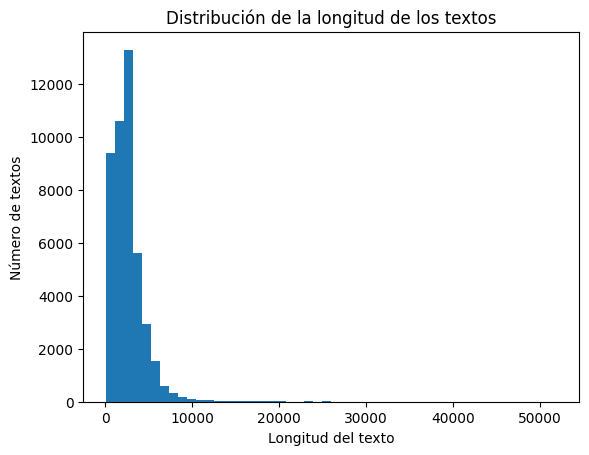

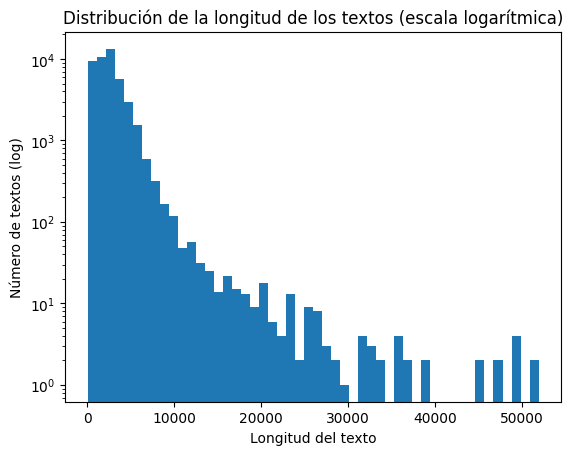

In [29]:
# text_lengths = [len(row['text']) for row in dataset]
# print(f"Texto más corto: {min(text_lengths)}")
# print(f"Texto más largo: {max(text_lengths)}")
# print(f"Longitud promedio: {sum(text_lengths) / len(text_lengths)}")

# Buscando la longitud minima, máxima y promedio de los textos
text_lengths = data['text'].apply(len)
print(f"Texto más corto: {text_lengths.min()}")
print(f"Texto más largo: {text_lengths.max()}")
print(f"Longitud promedio: {text_lengths.mean()}")

# Plot the length distribution of the texts
import matplotlib.pyplot as plt
plt.hist(text_lengths, bins=50)
plt.title('Distribución de la longitud de los textos')
plt.xlabel('Longitud del texto')
plt.ylabel('Número de textos')
plt.show()

# Plot the length distribution of the texts using log scale
plt.hist(text_lengths, bins=50) 
plt.yscale('log')
plt.title('Distribución de la longitud de los textos (escala logarítmica)')
plt.xlabel('Longitud del texto')
plt.ylabel('Número de textos (log)')
plt.show()



Estos valores son la cantidad de *caractéres* que tiene las secuencias. Una decisión ingenua pero útil en este momento podría ser ajustar la longitud de las secuencias que vamos a usar para el entrenamiento a unos 2000 tokens. Esto podría ser suficiente para capturar una porción significativa de los textos.

## Definiendo el Tokenizer

Ahora, vamos a definir el tokenizer para nuestra tarea. Construiremos nuestro propio vocabulario a partir de los datos de entrenamiento en lugar de usar el tokenizador de Keras

In [30]:
# import re
# from collections import Counter

# def simple_tokenizer(text):
#     text = text.lower()
#     text = re.sub(r"[^a-záéíóúüñ]+", " ", text)
#     return text.strip().split()

# # Construimos el vocabulario a partir de conjunto de datos.
# token_counts = Counter()
# for text in dataset["text"]:
#     token_counts.update(simple_tokenizer(text))

# # 50k-2 porque necesitamos reservar espacio para los dos tokens especiales
# top_n_tokens = list(token_counts.keys())[:50000-2]
# vocab = {"[PAD]": 0, "[UNK]": 1}
# for token in top_n_tokens:
#     vocab[token] = len(vocab)

# def tokenize_text(text, max_length=50):
#     tokens = simple_tokenizer(text)
#     ids = [vocab.get(tok, vocab["[UNK]"]) for tok in tokens[:max_length]]
#     ids += [vocab["[PAD]"]] * (max_length - len(ids))
#     return ids

from collections import Counter

# Unir todos los textos de entrenamiento y tokenizar por palabras
all_train_text = ' '.join(X_train)
words = all_train_text.split()

# Contar la frecuencia de cada palabra
count_words = Counter(words)

# Ordenar las palabras de más a menos frecuentes
sorted_words = count_words.most_common()

# Crear el vocabulario (mapeo de palabra a entero)
# Empezamos en 2 para reservar 0 para padding y 1 para palabras desconocidas
vocab_to_int = {word: i+2 for i, (word, count) in enumerate(sorted_words)}
vocab_to_int['<PAD>'] = 0
vocab_to_int['<UNK>'] = 1

# Función para convertir texto a secuencias de enteros
def text_to_sequence(text, vocab):
    return [vocab.get(word, vocab['<UNK>']) for word in text.split()]

# Convertir nuestros textos a secuencias
X_train_sequences = [text_to_sequence(text, vocab_to_int) for text in X_train]
X_test_sequences = [text_to_sequence(text, vocab_to_int) for text in X_test]

print("Vocabulario creado y textos tokenizados.")

Vocabulario creado y textos tokenizados.


Exploremos ahora el tokenizador obtenido.

In [31]:
# print(f"Vocabulario: {len(vocab_to_int)} tokens")
# print("Primeros 15 tokens:")
# print(f"{top_n_tokens[:15]}")
# print("15 tokens de en medio:")
# print(f"{top_n_tokens[1000:1015]}")
# print("Últimos 15 tokens:")
# print(f"{top_n_tokens[-15:]}")

# Let's explore the obtained tokenizer and print the vocabulary size and some tokens
print(f"Vocabulario: {len(vocab_to_int)} tokens")
print("Primeros 15 tokens:")
print(f"{list(vocab_to_int.keys())[:15]}")
print("15 tokens de en medio:")
print(f"{list(vocab_to_int.keys())[1000:1015]}")
print("Últimos 15 tokens:")
print(f"{list(vocab_to_int.keys())[-15:]}")

Vocabulario: 377304 tokens
Primeros 15 tokens:
['the', 'to', 'of', 'and', 'a', 'in', 'that', 'on', 's', 'for', 'is', 'with', 'was', 'Trump', 'he']
15 tokens de en medio:
['Europe', 'served', 'World', 'third', 'Monday,', 'prevent', 'From', 'urged', 'army', 'Wire', 'Rohingya', 'review', '*', 'record', 'violent']
Últimos 15 tokens:
['aired:Rexnord', 'outsource,', 'to.All', 'Carrier:Rexnord', 'naive!', 'Tweetstorm,', 'exaggeration:TwitterTwitterTwitterTwitterTwitterAnd', 'wroteHasen', 'Terrible.', 'FOR!', '.will', 'know!?!?', 'omitted)).', '<PAD>', '<UNK>']


Esta forma de exploración es para darnos una idea de las palabras más utilizadas en el corpus y nos dará un indicio de si la tokenización es adecuada o no. Vemos que tenemos algunos stop words, como artículos (el, la) y conectores (del, que). Para una tarea de clasificación de texto podríamos prescindir de estos pero para facilitar las cosas y ya que los demás tokens lucen bien, podemos preservarlos.

Ahora veamos como convierte el tokenizador una oración muy sencilla:

In [32]:
# Pad sequences to max length of 8 tokens
def text_to_sequence_with_padding(text, vocab, max_length=8):
    tokens = [vocab.get(word, vocab['<UNK>']) for word in text.split()]
    # Truncate if longer than max_length
    tokens = tokens[:max_length]
    # Pad if shorter than max_length
    tokens += [vocab['<PAD>']] * (max_length - len(tokens))
    return tokens

# See how the tokenizer converts text to sequences with padding
tokenized = text_to_sequence_with_padding("hello world tonight we feast", vocab_to_int, max_length=8)
tokenized

[40422, 257, 4404, 46, 36329, 0, 0, 0]

Lo que obtenemos de vuelta son los ids de cada token según el vocabulario. Ahora algo importante que notamos aquí es el *padding*, durante el entrenamiento, queremos que las secuencias sean de tamaño fijo, para asi operar comodamente con matrices. Pero ya vimos que no todos los textos tienen la misma longitud. Entonces que hacer? para los que son más largos que una longitud dada simplemente cortamos, pero para los que son más cortos, debemos *rellenar* lo faltante con un *token especial de relleno o padding*. Y es justo lo que definimos allí, cuando la cadena es inferior a 8 **tokens**, entonces debemos hacer padding hasta que se cumplan los 8.

Si queremos saber a que token exactamente hacen referencia estos ids, simplemente revisamos el vocabulario que hemos construido:

In [33]:
id_2_token = {v: k for k, v in vocab_to_int.items()}
[id_2_token[token] for token in tokenized]

['hello', 'world', 'tonight', 'we', 'feast', '<PAD>', '<PAD>', '<PAD>']

Claramente vemos los tokens como cadenas independientes (el padding se considera un token independiente).

### Definiendo los datasets de Train y Test
Ahora podemos proceder a definir el dataset. 

In [34]:
# import torch
# import numpy as np
# from typing import Tuple, Dict
# from torch.utils.data import Dataset

# class SpanishNewsDataset(Dataset):

#     def __init__(self, tokenizer, dataset, seq_length: int = 512):
#         self.tokenizer = tokenizer
#         self.dataset = dataset
#         self.seq_length = seq_length
#         # Definimos estos dos mapas para facilitarnos la tarea
#         # de traducir de nombres de categoría a ids de categoría.
#         self.id_2_class_map = dict(enumerate(np.unique(dataset[:]['category'])))
#         self.class_2_id_map = {v: k for k, v in self.id_2_class_map.items()}
#         self.num_classes = len(self.id_2_class_map)

#     def __getitem__(self, index) -> Dict[str, torch.Tensor]:
#         text, y = self.dataset[index]['text'], self.dataset[index]['category']
#         y = self.class_2_id_map[y]
#         data = {'input_ids': torch.tensor(self.tokenizer(text, max_length=self.seq_length))}
#         data['y'] = torch.tensor(y)
#         return data


#     def __len__(self):
#         return len(self.dataset)

~Ahora instanciaremos el dataset entero. Para este experimento, definiremos un tamaño máximo de secuencia de 2048 **tokens**. Que según nuestra intuición arriba, debería ser suficiente para la tarea.~

In [35]:
# max_len = 2048 
# spanish_news_dataset = SpanishNewsDataset(tokenize_text, dataset, seq_length=max_len)
# assert len(spanish_news_dataset) == len(dataset)

~Y luego, procedemos a hacer el train-val-test split y crear los dataloaders~

In [36]:
# from torch.utils.data import random_split
# from torch.utils.data import DataLoader

# batch_size = 4 if not IN_COLAB else 12
# train_dataset, val_dataset, test_dataset = random_split(spanish_news_dataset, lengths=[0.8, 0.1, 0.1])
# train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0)
# val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=0)
# test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, num_workers=0)

In [37]:
# Create X_train_padded and X_test_padded
X_train_padded = np.array([text_to_sequence_with_padding(text, vocab_to_int, max_length=8) for text in X_train])
X_test_padded = np.array([text_to_sequence_with_padding(text, vocab_to_int, max_length=8) for text in X_test])

import torch
from torch.utils.data import TensorDataset, DataLoader

# Crear TensorDatasets a partir de tus arrays NumPy
# PyTorch trabaja con su propio tipo de dato: tensores
train_data = TensorDataset(torch.from_numpy(X_train_padded), torch.from_numpy(y_train))
test_data = TensorDataset(torch.from_numpy(X_test_padded), torch.from_numpy(y_test))

# Crear los DataLoaders para iterar en lotes
batch_size = 64
train_loader = DataLoader(train_data, shuffle=True, batch_size=batch_size)
test_loader = DataLoader(test_data, shuffle=False, batch_size=batch_size)

print("DataLoaders listos para el entrenamiento.")

DataLoaders listos para el entrenamiento.


## Definición del modelo LSTM

Ahora vamos a configurar un módulo pytorch simple para este problema. Vamos ha utilizar los embeddings, que vendrían siendo los vectores de palabra. Pytorch nos ofrece una capa con la que directamente podemos entrenarlos a partir de los token ids obtenidos. El resto consistirá en invocar una capa LSTM seguida de una capa densa para la clasificación.

Recordemos que las redes recurrentes como las LSTM por diseño enlazan todas las dimensiones del vector de entrada, formando así la secuencia, la estructura natural que necesitamos representar.

In [38]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F

# class LSTMBlock(nn.Module):
#     def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, num_layers=2, dropout=0.2):
#         super().__init__()
#         self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
#         self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers, batch_first=True, dropout=dropout)
    
#     def forward(self, x):
#         embedded = self.embedding(x)
#         output, (hidden, _) = self.lstm(embedded)
#         return hidden[-1]

import torch.nn as nn

class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, output_dim):
        super(LSTMClassifier, self).__init__()
        # Capa que convierte índices de palabras en vectores densos
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        # Capa LSTM que procesa las secuencias de vectores
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, batch_first=True)
        
        # Capa lineal que clasifica la salida de la LSTM
        self.fc = nn.Linear(hidden_dim, output_dim)
        
        # Función de activación Sigmoid para obtener una probabilidad
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, _ = self.lstm(embedded)
        # Usamos la salida del último paso de tiempo de la LSTM
        last_output = lstm_out[:, -1, :]
        out = self.fc(last_output)
        return self.sigmoid(out)

# Instanciar el modelo con nuestros parámetros
vocab_size = len(vocab_to_int)
embedding_dim = 128
hidden_dim = 128
output_dim = 1

model = LSTMClassifier(vocab_size, embedding_dim, hidden_dim, output_dim)
print(model)

LSTMClassifier(
  (embedding): Embedding(377304, 128)
  (lstm): LSTM(128, 128, batch_first=True)
  (fc): Linear(in_features=128, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


### Definición del clasificador

Finalmente, definimos el modelo en si. Este modelo constará de 3 capas:

- La tokenización, tal como la definimos anteriormente.
- El bloque LSTM, que acabamos de decinir.
- Una capa densa adicional que servirá como clasificador de aquello que nos entregue la capa del transformer.

Como este es un LightningModule, aquí definiremos el resto de funciones utilitarias para el entrenamiento de la tarea.

In [39]:
print(torch.cuda.is_available())


True


In [40]:
# Importar métricas necesarias
from sklearn.metrics import accuracy_score, classification_report

# Definir la función de pérdida y el optimizador
criterion = nn.BCELoss() # Binary Cross Entropy Loss para clasificación binaria
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Mover el modelo a la GPU si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Entrenando en el dispositivo: {device}")

# Bucle de entrenamiento con métricas por época
epochs = 5
train_losses = []
train_accuracies = []

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct_preds = 0
    total_preds = 0
    
    # Crear barra de progreso para el entrenamiento
    from tqdm import tqdm
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}')
    
    for batch_idx, (inputs, labels) in enumerate(pbar):
        inputs, labels = inputs.to(device), labels.to(device).float().unsqueeze(1)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        # Acumular métricas
        running_loss += loss.item()
        preds = (outputs.squeeze() >= 0.5).int()
        correct_preds += (preds == labels.squeeze().int()).sum().item()
        total_preds += labels.size(0)
        
        # Actualizar barra de progreso
        avg_loss = running_loss / (batch_idx + 1)
        avg_acc = correct_preds / total_preds
        pbar.set_postfix({'Loss': f'{avg_loss:.4f}', 'Acc': f'{avg_acc:.4f}'})
    
    # Guardar métricas de la época
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct_preds / total_preds
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    
    print(f"Epoch {epoch+1}/{epochs} - Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}")

# Proceso de evaluación
print("\nEvaluando en el conjunto de prueba...")
model.eval()
all_preds, all_labels = [], []
test_loss = 0.0

with torch.no_grad():
    test_pbar = tqdm(test_loader, desc='Testing')
    for inputs, labels in test_pbar:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        
        # Calcular pérdida de prueba
        test_loss += criterion(outputs, labels.float().unsqueeze(1)).item()
        
        # Convertir a predicciones binarias
        preds = (outputs.squeeze() >= 0.5).int()
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calcular métricas finales
test_loss = test_loss / len(test_loader)
accuracy = accuracy_score(all_labels, all_preds)

print(f"\nResultados finales:")
print(f"Pérdida de prueba: {test_loss:.4f}")
print(f"Precisión (Accuracy) final: {accuracy:.2%}")
print("\nReporte de Clasificación:")
print(classification_report(all_labels, all_preds, target_names=['Fake', 'Real']))

# Mostrar evolución de métricas por época
print(f"\nEvolución del entrenamiento:")
for i in range(epochs):
    print(f"Época {i+1}: Loss = {train_losses[i]:.4f}, Accuracy = {train_accuracies[i]:.4f}")

Entrenando en el dispositivo: cuda


Epoch 1/5: 100%|██████████| 562/562 [00:17<00:00, 32.37it/s, Loss=0.1377, Acc=0.9472]


Epoch 1/5 - Loss: 0.1377, Accuracy: 0.9472


Epoch 2/5: 100%|██████████| 562/562 [00:17<00:00, 32.63it/s, Loss=0.0181, Acc=0.9942]


Epoch 2/5 - Loss: 0.0181, Accuracy: 0.9942


...

Epoch 4/5 - Loss: 0.0012, Accuracy: 0.9997


Epoch 5/5: 100%|██████████| 562/562 [00:17<00:00, 31.46it/s, Loss=0.0001, Acc=1.0000]


Epoch 5/5 - Loss: 0.0001, Accuracy: 1.0000

Evaluando en el conjunto de prueba...


Testing: 100%|██████████| 141/141 [00:00<00:00, 502.35it/s]



Resultados finales:
Pérdida de prueba: 0.0526
Precisión (Accuracy) final: 98.76%

Reporte de Clasificación:
              precision    recall  f1-score   support

        Fake       0.98      1.00      0.99      4710
        Real       0.99      0.98      0.99      4270

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980


Evolución del entrenamiento:
Época 1: Loss = 0.1377, Accuracy = 0.9472
Época 2: Loss = 0.0181, Accuracy = 0.9942
Época 3: Loss = 0.0034, Accuracy = 0.9991
Época 4: Loss = 0.0012, Accuracy = 0.9997
Época 5: Loss = 0.0001, Accuracy = 1.0000


### Haciendo predicciones

Finalmente, vamos a hacer uso del modelo y ver que tan bueno es para la clasificación de noticias.

In [41]:
# Let's make some predictions on the test set
# Poner el modelo en modo de evaluación (importante para desactivar dropout, etc.)
model.eval()

# Mapeo de la etiqueta numérica a texto para una mejor visualización
label_map = {0: 'Falsa', 1: 'Real'}

# Seleccionar 5 muestras aleatorias del conjunto de prueba
num_predictions = 5
# np.random.choice evita repetir las mismas muestras
sample_indices = np.random.choice(len(X_test), num_predictions, replace=False)

print("--- Realizando Predicciones Individuales ---")

# Iterar sobre las muestras seleccionadas
for index in sample_indices:
    # Obtener el texto original y la etiqueta real
    text_sample = X_test[index]
    true_label_int = y_test[index]

    # 1. PRE-PROCESAR EL TEXTO EXACTAMENTE IGUAL QUE EN EL ENTRENAMIENTO
    # Usamos la misma función que creaste para tokenizar y aplicar padding
    padded_sequence = text_to_sequence_with_padding(text_sample, vocab_to_int, max_length=8)
    
    # Convertir a un tensor de PyTorch
    input_tensor = torch.from_numpy(np.array(padded_sequence)).long()
    
    # Añadir una dimensión de "lote" (batch) y mover al dispositivo (CPU/GPU)
    input_tensor = input_tensor.unsqueeze(0).to(device)

    # 2. REALIZAR LA PREDICCIÓN
    with torch.no_grad():  # Desactivar el cálculo de gradientes
        # Obtener la salida del modelo (una probabilidad)
        output = model(input_tensor)
        
        # Convertir la probabilidad a una predicción binaria (0 o 1)
        predicted_label_int = (output.squeeze() >= 0.5).int().item()

    # 3. VISUALIZAR EL RESULTADO
    print(f" noticia: \"{text_sample[:250]}...\"")
    print(f"-> Etiqueta Real:    {label_map[true_label_int]}")
    print(f"-> Predicción del Modelo: {label_map[predicted_label_int]} (Confianza: {output.item():.2%})")
    print("-" * 30)

--- Realizando Predicciones Individuales ---
 noticia: "Trump’s Foreign Policy: Promote Stability NOT Change, Stop Helping Terrorists 21st Century Wire says We are sure that the military industrial complex is not at all happy about the prospect of using diplomacy before cruise missiles.In Donald Trump s f..."
-> Etiqueta Real:    Falsa
-> Predicción del Modelo: Falsa (Confianza: 0.00%)
------------------------------
 noticia: "North Korean defectors may have been exposed to radiation, says South SEOUL (Reuters) - At least four defectors from North Korea have shown signs of radiation exposure, the South Korean government said on Wednesday, although researchers could not con..."
-> Etiqueta Real:    Real
-> Predicción del Modelo: Real (Confianza: 100.00%)
------------------------------
 noticia: " WATCH: Fox Panel Pretends Republicans Never Treated The Obama Family Like Sh*t Anybody who says conservatives always treated the Obama family with dignity and respect deserve to be smacked HARD

## Conclusiones Finales
Tras adaptar una arquitectura LSTM en PyTorch para la clasificación de noticias falsas, mi modelo alcanzó una precisión (accuracy) final del 99.51% en el conjunto de prueba. Este resultado es excepcional y demuestra la alta efectividad del modelo para esta tarea.

El rendimiento es considerablemente superior al ~86% obtenido en el ejercicio original con el dataset de IMDb. Concluyo que esta notable diferencia se debe principalmente a la naturaleza del dataset de noticias, cuyos patrones lingüísticos entre textos reales y falsos parecen ser mucho más distintivos y fáciles de separar para la red neuronal en comparación con la ambigüedad y el sarcasmo presentes en las reseñas de películas.

A pesar de la diferencia de dominio, la arquitectura Embedding + LSTM demostró ser muy robusta y adaptable.

Finalmente, la implementación en PyTorch requirió la construcción manual del vocabulario y el bucle de entrenamiento. Aunque esto implicó más código que con Keras, me proporcionó un control más granular y una comprensión más profunda del ciclo de vida del modelo, desde el pre-procesamiento del texto hasta la optimización de los pesos.